# Applied TM 1: **Assignment 2**:  
### Fine-tuning BERT on negation scope detection: a token classification task
#### Name (VUid): Rey Rashid
#### Group 4 (Manar Attar, Keze Hu, Carmen Popa, Rey Rashid)
#### Notebook adapted from: https://github.com/cltl/ma-ml4nlp-labs/blob/main/code/assignment3/other_systems/bert_finetunen.ipynb

Link to download the mode (seed 42): https://drive.google.com/file/d/1sQsY7kS2QI744VlB-Im3LhVdmfrnpMB3/view?usp=sharing

### **Notebook Setup**

Let's install the packages we need from 🤗 : Transformers, Datasets, Seqeval, and Evalaute

In [2]:
# ! pip install transformers datasets seqeval evaluate
import util
import numpy as np
import pandas as pd
from collections import Counter
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification,
    TrainingArguments, 
    Trainer,
    DataCollatorForTokenClassification,
    set_seed
)
from evaluate import load
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### **Task Definition: Negation Scope Detection**

#Note: The following explanation is adapted from the four course papers

Negation Scope Detection is a is a sequence labeling task where we identify which tokens of a sentence are affected by a negation cue. Negation is a grammatical category used to reverse the truth value of a proposition, and its scope is defined as the specific part of that meaning being negated. Resolving this scope is essential for tasks such as sentiment analysis, question answering, and information extraction, because it prevents systems from incorrectly interpreting negated statements as affirmative facts. Systems such as those from the University of Michigan (Abu-Jbara and Radev, 2012) and the University of Oslo (Lapponi et al., 2012) use features like Part-of-Speech tags to help models learn which grammatical categories are likely to fall within a scope. The task typically involves three subtasks: identifying the negation cue, resolving the scope, and identifying the negated event or property that is being negated.

Examples of this task include sentences such as "[John had] never [said as much before]," where "never" is the negation cue and the tokens in brackets are within its scope. Another example is "[Andrew had] never [liked smart phones]," in which "never" is the cue, the bracketed text is the scope, and the word "liked" represents the negated event. Furthermore, negation can be morphological, as seen in the word "un[fortunate]," where the prefix is the cue and the rest of the word is the scope. Determining these boundaries can be complex because both negation cues and scopes can be discontinuous, such as in the case of "neither [...] nor" or in sentences where the scope includes tokens appearing both before and after the cue. The FBK system (Chowdhury, 2012) specifically noted that identifying these boundaries often requires the exploitation of phrasal and contextual clues

### **0 Datasets: Statistics Summary**

We use the SEM 2012 Shared Task corpora for negation analysis, containing Conan Doyle stories annotated for negation cues, their scopes, and negated events. Cues are not part of the scope, and both cues and scopes can be discontinuous. The dataset is distributed in a CoNLL-style format with tokens, lemmas, POS tags, and syntactic parse information.
The dataset was transformed into 10-columns CoNLL format for our pipeline, with duplication for sentences that contain more than one negation cue. The statistics are computed before and after preprocessing.

In [3]:
#Data Loading and Statistics
#Dataset paths before transdormation
data_folder = '../data/cd-sco/corpus'
training_file_raw = data_folder + '/training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt'
dev_file_raw = data_folder + '/dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt'
test_file_gold_raw= data_folder + '/test-gold/test_combined_with_gold.txt' #final test set file without gold

#dataset paths after transformation
train_trans= '../data/training.conll'
dev_trans= '../data/dev.conll'
test_trans= '../data/test_with_gold.conll'

#transforming the dataset to CoNLL format using the util function developed in A1
transformed_train= util.format_transformation (training_file_raw, train_trans)
transformed_development= util.format_transformation (dev_file_raw, dev_trans)
transformed_test= util.format_transformation (test_file_gold_raw, test_trans)

In [4]:
#Statistics Before and After Transformation

#training set
b4_train_sent, b4_train_token = util.extracting_sent_token_before_preprocessing(training_file_raw)
print (f'The number of sentences in the training set before transformation: {len(b4_train_sent)}')
print (f'The number of tokens in the training set before transformation: {len(b4_train_token)}')

af_train_sents, af_train_tokens, af_train_cues, af_train_tokens_in_scopes_count= util.extracting_info_after_preprocessing (train_trans)

util.statistic_after_trans(af_train_sents, af_train_tokens, af_train_cues, af_train_tokens_in_scopes_count, set_name= 'training')


The number of sentences in the training set before transformation: 3644
The number of tokens in the training set before transformation: 65451
The number of sentences in the training set after transformation: 3780
The number of tokens in the training set after transformation: 69218
The number of all cue instances in the training set after transformation: 984
The number of word tokens in all negation cues in the training data set after transformation: 1003
The number of unique cue forms in the training set after transformation: 30
Cue Frequency distribution: Counter({'not': 356, 'no': 226, 'un': 80, "n't": 65, 'never': 59, 'nothing': 55, 'less': 28, 'without': 24, 'in': 22, 'im': 18, 'none': 12, 'nor': 6, 'ir': 6, 'dis': 5, 'by no means': 3, 'on the contrary': 2, 'neither nor': 2, 'prevent': 2, 'nowhere': 2, 'save': 1, 'nobody': 1, 'rather than': 1, 'not for the world': 1, 'fail': 1, 'except': 1, 'nothing at all': 1, 'neglected': 1, 'refused': 1, 'not not': 1, 'absence': 1})
The number o

In [5]:
#development set

b4_dev_sent, b4_dev_token = util.extracting_sent_token_before_preprocessing(dev_file_raw)
print (f'The number of sentences in the development set before transformation: {len(b4_dev_sent)}')
print (f'The number of tokens in the development set before transformation: {len(b4_dev_token)}')

af_dev_sents, af_dev_tokens, af_dev_cues, af_dev_tokens_in_scopes_count= util.extracting_info_after_preprocessing (dev_trans)
util.statistic_after_trans(af_dev_sents, af_dev_tokens, af_dev_cues, af_dev_tokens_in_scopes_count, set_name= 'dev')

The number of sentences in the development set before transformation: 787
The number of tokens in the development set before transformation: 13567
The number of sentences in the dev set after transformation: 816
The number of tokens in the dev set after transformation: 14272
The number of all cue instances in the dev set after transformation: 173
The number of word tokens in all negation cues in the dev data set after transformation: 179
The number of unique cue forms in the dev set after transformation: 20
Cue Frequency distribution: Counter({'not': 42, 'no': 32, "n't": 20, 'un': 16, 'nothing': 16, 'never': 11, 'without': 7, 'im': 6, 'in': 5, 'nor': 4, 'less': 3, 'neither nor': 2, 'dis': 2, 'no nor': 1, 'by no means': 1, 'neither': 1, 'ir': 1, 'save': 1, 'nobody': 1, 'no more': 1})
The number of tokens in scope after dev set transformation: 1368
The number of tokens outside the scope after dev set transformation: 12904


In [6]:
#test set
b4_test_sent, b4_test_token = util.extracting_sent_token_before_preprocessing(test_file_gold_raw)
print (f'The number of sentences in the test set before transformation: {len(b4_test_sent)}')
print (f'The number of tokens in the test set before transformation: {len(b4_test_token)}')
af_test_sents, af_test_tokens, af_test_cues, af_test_tokens_in_scopes_count= util.extracting_info_after_preprocessing (test_trans)
util.statistic_after_trans(af_test_sents, af_test_tokens, af_test_cues, af_test_tokens_in_scopes_count, set_name= 'test')

The number of sentences in the test set before transformation: 1089
The number of tokens in the test set before transformation: 19216
The number of sentences in the test set after transformation: 1118
The number of tokens in the test set after transformation: 19915
The number of all cue instances in the test set after transformation: 264
The number of word tokens in all negation cues in the test data set after transformation: 274
The number of unique cue forms in the test set after transformation: 20
Cue Frequency distribution: Counter({'not': 82, 'no': 50, "n't": 34, 'nothing': 22, 'never': 20, 'un': 19, 'without': 7, 'less': 5, 'in': 4, 'im': 3, 'neither nor': 3, 'dis': 3, 'nor': 3, 'ir': 2, 'no more': 2, 'far from': 1, 'neither nor nor': 1, 'none': 1, 'absolutely nothing': 1, 'never more': 1})
The number of tokens in scope after test set transformation: 1826
The number of tokens outside the scope after test set transformation: 18089


### **3 Preprocessing**

#### 3.1 Input Preprocessing (Cue Encoding)

Using BERT for Negation Scope Detection
BERT (Bidirectional Encoder Representations from Transformers) can be fine-tuned for token classification tasks. In standard token classification, each token is labeled independently. But in negation scope detection, the labels depend on which cue's scope we're detecting. A sentence like "This is **not** an **un**important task" has two cues, each with different scopes. We can use the approach from NegBERT (Khandelwal & Sawant, 2020), which encodes the negation cue information directly in the input tokens: 

We use the cue replacement method so each negation cue in a sentence is replaced depending on its type: 

[CUE_0] - Affix cue (e.g., unhappy) 

[CUE_1] - Single-word cue (e.g., not) 

[CUE_2] - Part of a multi-word cue (e.g., by no means) 

Non-cue tokens remain unchanged.

Scope labels are encoded in binary form: 
0: Outside the cue’s scope 
1: Inside the cue’s scope 

This way, BERT learns to associate scope labels with the presence and type of cue. Let's see examples of how sentences are preprocessed:

In [7]:
#Get preprocessed data using the replace method
all_train_sentences, all_train_labels = util.preprocessing_neg_bert(train_trans)
all_dev_sentences, all_dev_labels = util.preprocessing_neg_bert(dev_trans)
all_test_sentences, all_test_labels = util.preprocessing_neg_bert(test_trans)

In [8]:
print("Example 1:")
print(f"Preprocessed tokens: {all_train_sentences[51]}")
print(f"Scope labels:    {all_train_labels[51]}")
print()

Example 1:
Preprocessed tokens: ['``', 'No', ',', '[CUE_1]', ',', 'my', 'dear', 'Watson', ',', 'not', 'all', '--', 'by', 'no', 'means', 'all', '.']
Scope labels:    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



In [9]:
print("Example 2:")
print(f"Preprocessed tokens: {all_train_sentences[53]}")
print(f"Scope labels:        {all_train_labels[53]}")

Example 2:
Preprocessed tokens: ['``', 'No', ',', 'no', ',', 'my', 'dear', 'Watson', ',', 'not', 'all', '--', '[CUE_2]', '[CUE_2]', '[CUE_2]', 'all', '.']
Scope labels:        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]


#### 3.2 Creating datasets

Converting Data to HuggingFace Dataset Format

In [10]:
def create_dataset_dict(sentences, labels):
    """Convert our data format to HuggingFace Dataset format."""
    return Dataset.from_dict({
        'tokens': sentences,
        'scope_labels': labels})

In [11]:
# Create datasets
train_dataset = create_dataset_dict(all_train_sentences, all_train_labels)
dev_dataset = create_dataset_dict(all_dev_sentences, all_dev_labels)
test_dataset = create_dataset_dict(all_test_sentences, all_test_labels)

In [12]:
#Combine into DatasetDict
datasets = DatasetDict({
    'train': train_dataset,
    'validation': dev_dataset,
    'test': test_dataset})

In [13]:
print(datasets)
print("\nExample from training set:")
print(datasets['train'][53])

DatasetDict({
    train: Dataset({
        features: ['tokens', 'scope_labels'],
        num_rows: 3780
    })
    validation: Dataset({
        features: ['tokens', 'scope_labels'],
        num_rows: 816
    })
    test: Dataset({
        features: ['tokens', 'scope_labels'],
        num_rows: 1118
    })
})

Example from training set:
{'tokens': ['``', 'No', ',', 'no', ',', 'my', 'dear', 'Watson', ',', 'not', 'all', '--', '[CUE_2]', '[CUE_2]', '[CUE_2]', 'all', '.'], 'scope_labels': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}


In [14]:
# Define label list for scope detection (binary classification)
label_list = ['0', '1']  # 0 = Outside scope, 1 = Inside scope
task = "negation scope detection"
print(f"Label list: {label_list}")
print(f"Number of labels: {len(label_list)}")

Label list: ['0', '1']
Number of labels: 2


### 3.3 BERT Input preprocessing

Tokenization and Label Alignment

BERT uses subword tokenization (WordPiece), so a single word can be split into multiple subtokens (e.g., "unhappy" will be ["un", "##happy"]). Since the scope labels are word level, we need to align them with the subtokens. 

Special tokens like [CLS] and [SEP] are assigned -100 so they are ignored during loss computation. The first subtoken of a word receives the original label, while subsequent subtokens either receive the same label (if training all subtokens) or are set to -100 to be ignored in loss computation. 

For example, for the tokens ["unhappy", "child"] with labels [1, 0], the subtokens ["un", "##happy", "child"] would have aligned labels [1, 1, 0] if label_all_tokens=True or [1, -100, 0] otherwise. 

This keeps the token-level scope labels consistent with BERT’s subword tokenization, which is needed for using BERT for token classification tasks.

Note: special tokens like [CLS] and [SEP] are added by the tokenizer to mark the beginning and end of a sentence. They are embedded in the tokenizer. 

In [15]:
#Model configuration
model_checkpoint = "distilbert-base-uncased"

In [16]:
#Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
#Load pre-trained BERT model 
model =  AutoModelForTokenClassification.from_pretrained(model_checkpoint)

Some weights of DistilBertForTokenClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

Tokenizer: DistilBertTokenizerFast
Vocabulary size: 30522


In [18]:
#adding replacement labels as special tokens
###code adapted from: https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PythonBackend.add_tokens.special_tokens,
  #last accessed 22 Jan
new_tokens= ["[CUE_1]","[CUE_2]","[CUE_0]"]
num_added_tokens= tokenizer.add_special_tokens({"additional_special_tokens":new_tokens} )
print(num_added_tokens, "tokens added")
# Notice: resize_token_embeddings expect to receive the full size of the new vocabulary, i.e., the length of the tokenizer.
model.resize_token_embeddings(len(tokenizer))

3 tokens added


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(30525, 768, padding_idx=0)

word_ids(): Shows which original word each subword belongs to
 - `None` indicates special tokens ([CLS], [SEP])
 - Same number indicates subwords from the same original token

In [19]:
# Test tokenization on an example
example_tokens = all_train_sentences[16]
example_labels = all_train_labels[16]
print("\nOriginal tokens (human-readable):", example_tokens)
print("Original labels (human-readable):", example_labels)


Original tokens (human-readable): ['Since', 'we', 'have', 'been', 'so', 'unfortunate', 'as', 'to', 'miss', 'him', 'and', 'have', '[CUE_1]', 'notion', 'of', 'his', 'errand', ',', 'this', 'accidental', 'souvenir', 'becomes', 'of', 'importance', '.']
Original labels (human-readable): [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:
#Tokenize with special token added
tokenized = tokenizer(example_tokens, is_split_into_words=True)
print("Subword tokens:", tokenizer.convert_ids_to_tokens(tokenized['input_ids']))
print("Subword tokens (machine-readable):", tokenized['input_ids'])
print("Word IDs mapping:", tokenized.word_ids())

Subword tokens: ['[CLS]', 'since', 'we', 'have', 'been', 'so', 'unfortunate', 'as', 'to', 'miss', 'him', 'and', 'have', '[CUE_1]', 'notion', 'of', 'his', 'er', '##rand', ',', 'this', 'accidental', 'so', '##uven', '##ir', 'becomes', 'of', 'importance', '.', '[SEP]']
Subword tokens (machine-readable): [101, 2144, 2057, 2031, 2042, 2061, 15140, 2004, 2000, 3335, 2032, 1998, 2031, 30522, 9366, 1997, 2010, 9413, 13033, 1010, 2023, 17128, 2061, 27346, 4313, 4150, 1997, 5197, 1012, 102]
Word IDs mapping: [None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 16, 17, 18, 19, 20, 20, 20, 21, 22, 23, 24, None]


In [21]:
#Tokenization function with label alignment
label_all_tokens = True  # Set to False to only label first subword of each token

In [22]:
#code to ensure the length of sub-tokens align with labels
def tokenize_and_align_labels(dataset):
    """
    Tokenize inputs and align labels with subword tokens.
    
    Each token is split into multiple subwords:
    - First subword gets the original label
    - Other subwords get the same label if label_all_tokens=True, else -100
    - Special tokens (CLS, SEP) get -100 (ignored in loss)

    Parameter:
    dataset
    dataset dict, such as dataset['train'])
    """
    tokenized_inputs = tokenizer(dataset["tokens"], truncation=True, is_split_into_words=True)
    
    labels = []
    for i, label in enumerate(dataset["scope_labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        
        for word_idx in word_ids:
            # Special tokens have word_idx = None, label = -100 (ignored)
            if word_idx is None:
                label_ids.append(-100)
            # First subword of a token, uses original label
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            #other subwords, copy label or -100
            else:
                label_ids.append(label[word_idx] if label_all_tokens else -100)
            
            previous_word_idx = word_idx
        
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [23]:
tokenize_and_align_labels(datasets['train'][16:17])

{'input_ids': [[101, 2144, 2057, 2031, 2042, 2061, 15140, 2004, 2000, 3335, 2032, 1998, 2031, 30522, 9366, 1997, 2010, 9413, 13033, 1010, 2023, 17128, 2061, 27346, 4313, 4150, 1997, 5197, 1012, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'labels': [[-100, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -100]]}

In [24]:
#tokenize the whole dataset
tokenized_datasets = datasets.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3780 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/1118 [00:00<?, ? examples/s]

In [25]:
print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'scope_labels', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3780
    })
    validation: Dataset({
        features: ['tokens', 'scope_labels', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 816
    })
    test: Dataset({
        features: ['tokens', 'scope_labels', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 1118
    })
})


In [26]:
# label values
label_values = set([0, 1])

#check if any label appears in input_ids
def check_input_ids_for_labels(dataset):
    for split_name, split_data in dataset.items():
        for i, input_ids in enumerate(split_data['input_ids']):
            # check intersection between input_ids and label values
            if set(input_ids) & label_values:
                print(f"Found label in input_ids at {split_name}[{i}]")
                return
    print("No labels in input_ids.")

# Run the check
check_input_ids_for_labels(tokenized_datasets)

No labels in input_ids.


In [27]:
#Example of tokenized model input
example_batch = datasets["train"][:17]
tokenized_example = tokenize_and_align_labels(example_batch)

print("Example: tokenization and label alignment (training data)")

print("Original tokens:", example_batch["tokens"][16])
print("Original labels:", example_batch["scope_labels"][16])

input_ids = tokenized_example["input_ids"][16]
labels = tokenized_example["labels"][16]

subword_tokens = tokenizer.convert_ids_to_tokens(input_ids)
label_names = [label_list[l] if l != -100 else "-" for l in labels]

for token, label in zip(subword_tokens, label_names):
    print(token, ",", label)


Example: tokenization and label alignment (training data)
Original tokens: ['Since', 'we', 'have', 'been', 'so', 'unfortunate', 'as', 'to', 'miss', 'him', 'and', 'have', '[CUE_1]', 'notion', 'of', 'his', 'errand', ',', 'this', 'accidental', 'souvenir', 'becomes', 'of', 'importance', '.']
Original labels: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[CLS] , -
since , 0
we , 1
have , 0
been , 0
so , 0
unfortunate , 0
as , 0
to , 0
miss , 0
him , 0
and , 0
have , 1
[CUE_1] , 0
notion , 1
of , 1
his , 1
er , 1
##rand , 1
, , 0
this , 0
accidental , 0
so , 0
##uven , 0
##ir , 0
becomes , 0
of , 0
importance , 0
. , 0
[SEP] , -


### **4 BERT Finetuning**

#Note: The given notebook was used in the explanations.

We now fine-tune a pretrained BERT model for our negation scope detection task, using the Hugging Face Trainer API. The steps are as follows:

-We set the evaluation to be done at the end of each epoch, set training arguments such as learning rate, batch size, number of epochs for training, weight decay, and the random seed. 
The seed affects weight initialization and data order, ultimately leading to slightly different results. Setting the random seed ensures reproducibility of the results.

-We use a data collator from the Transformers library that will batch our processed examples together while applying padding to make them all the same size (each pad will be padded to the length of its longest example). This collator not only pads the inputs, but also the labels.

-Create the Trainer with the model, training arguments, datasets, tokenizer, data collator, and metric function.

-Train and evaluate the model. Fine-tuning adjusts BERT’s contextual embeddings to detect which tokens are within the scope of a negation cue.

In [28]:
batch_size = 16
# Set random seed!
SEED = 42 # individual: testing different seeds
set_seed(SEED)
#Training arguments
model_name = model_checkpoint.split("/")[-1]
args = TrainingArguments(
    f"{model_name}-finetuned-{task}",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    seed=SEED,
    report_to=None,
)

In [29]:
#Data collator
data_collator = DataCollatorForTokenClassification(tokenizer)

In [30]:
print(tokenized_datasets["test"].column_names)

['tokens', 'scope_labels', 'input_ids', 'attention_mask', 'labels']


In [31]:
#Create Trainer
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"], #this might need to be changed to testset
    data_collator=data_collator,
    tokenizer=tokenizer)

C:\Users\Rey\AppData\Local\Temp\ipykernel_16572\2730927414.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


We didn't load and compute matrixs becausse we will use a customized evaluation in section 6. As a result, you will only see loss values when running the cell. Other standard metrics (Precision, Recall, and F1) are not there because we didn't pass that to the Trainer.

In [32]:
# Train the model
trainer.train()

C:\Users\Rey\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,0.085259
2,No log,0.073561
3,0.089500,0.079508


C:\Users\Rey\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=711, training_loss=0.07087028211011498, metrics={'train_runtime': 966.1049, 'train_samples_per_second': 11.738, 'train_steps_per_second': 0.736, 'total_flos': 141097182215808.0, 'train_loss': 0.07087028211011498, 'epoch': 3.0})

In [33]:
trainer.evaluate()

{'eval_loss': 0.07950765639543533,
 'eval_runtime': 14.44,
 'eval_samples_per_second': 56.51,
 'eval_steps_per_second': 3.532,
 'epoch': 3.0}

### **5 Postprocessing**

Post-processing and Evaluation on Test Set

BERT produces predictions at the subword level because it uses WordPiece tokenization. As valuation is done at the token level (the original CoNLL format), we need to convert subword-level predictions back to token-level predictions. For each sentence, we re-tokenize the original tokens with is_split_into_words=True to obtain a word_ids mapping, which tells us which subtokens belong to the same original word.

For each original token, we collect all predictions from its subtokens, and apply majority voting to select the final label. If there is a tie, we use the prediction from the first subtoken.

To select the final label for each token, we collect all predictions from its subtokens and apply majority voting. If there is a tie, we select the prediction from the first subtoken. We can then ensure each original token gets exactly one prediction, enabling correct evaluation on the test set.

Example:
Original tokens: ["unhappy", "child"]
Subword tokens: ["un", "##happy", "child"]
Subword predictions: [1, 0, 0]
Token-level predictions: [1, 0] (majority vote, first subword used if tie)

In [34]:
def align_predictions_with_tokens(predictions, original_tokens_list, loaded_tokenizer=tokenizer):
    """
    Convert subword predictions back to token-level predictions.
    Majority voting among subword predictions for each token.
    In case of a tie, use the prediction from the first subword.
    
    Returns:
    --------
    token_predictions : list of lists
    """
    token_predictions = []
    # Override tokenizer if given
    if loaded_tokenizer:
        tokenizer = loaded_tokenizer
    

    
    for pred_seq, orig_tokens in zip(predictions, original_tokens_list):
        # Tokenize to get word_ids mapping
        tokenized = tokenizer(orig_tokens, is_split_into_words=True, truncation=True)
        word_ids = tokenized.word_ids()
        
        # Store votes and first label for each original token
        votes = {}
        first_labels = {}
        
        for i, word_idx in enumerate(word_ids):
            # Skip special tokens
            if word_idx is None:
                continue
            
            # Get label prediction for current subword
            label_id = int(pred_seq[i])
            
            # Group predictions for subwords with same word_idx
            if word_idx not in votes:
                votes[word_idx] = []
                first_labels[word_idx] = label_id
            votes[word_idx].append(label_id)
        
        #majority vote for each token
        sentence_preds = []
        for word_idx in sorted(votes.keys()):
            word_votes = votes[word_idx]
            counts = Counter(word_votes)
            
            #max frequency
            max_freq = max(counts.values())
            
            #Collect all candidates with max frequency
            candidates = []
            for label, count in counts.items():
                if count == max_freq:
                    candidates.append(label) 
            
            #use first subword's prediction if there's a tie
            if len(candidates) > 1:
                final_label = first_labels[word_idx]
            else:
                final_label = candidates[0]
            
            sentence_preds.append(final_label)
        
        token_predictions.append(sentence_preds)
    
    return token_predictions

In [35]:
#predicting on the test set
test_output = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(test_output.predictions, axis=2)

In [36]:
print(predictions[1078])

[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]


In [37]:
#Example of converting subword predictions to token-level predictions for one sentence
tokens = all_test_sentences[1078]
subword_preds = predictions[1078:1079]  
original_tokens = [tokens]

# Apply alignment function
token_level_preds = align_predictions_with_tokens(
    subword_preds,
    original_tokens,
    tokenizer)

tokenized = tokenizer(tokens, is_split_into_words=True)
subwords = tokenizer.convert_ids_to_tokens(tokenized["input_ids"])
word_ids = tokenized.word_ids()

print("Original tokens:", tokens)
print("Subwords:", subwords)
print("Word IDs:", word_ids)
print("Subword predictions:", subword_preds[0].tolist())
print("Token-level predictions:", token_level_preds[0])

Original tokens: ['He', 'struck', 'Gennaro', 'senseless', 'and', 'fled', 'from', 'the', 'house', 'which', 'he', 'was', '[CUE_2]', '[CUE_2]', 'to', 'enter', '.']
Subwords: ['[CLS]', 'he', 'struck', 'gen', '##nar', '##o', 'sense', '##less', 'and', 'fled', 'from', 'the', 'house', 'which', 'he', 'was', '[CUE_2]', '[CUE_2]', 'to', 'enter', '.', '[SEP]']
Word IDs: [None, 0, 1, 2, 2, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, None]
Subword predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Token-level predictions: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0]


In [38]:
#Align with original tokens
test_token_predictions = align_predictions_with_tokens(predictions, all_test_sentences)

print(f"Number of sentences: {len(test_token_predictions)}")
print(f"Number of gold label sentences: {len(all_test_labels)}")

#check counts match
total_predicted = sum(len(sent) for sent in test_token_predictions)
total_gold = sum(len(sent) for sent in all_test_labels)

print(f"Total predicted tokens: {total_predicted}")
print(f"Total gold tokens: {total_gold}")

Number of sentences: 1118
Number of gold label sentences: 1118
Total predicted tokens: 19915
Total gold tokens: 19915


### **6 Result and evaluation**

In [39]:
def calculate_matrices (gold_labels, predictions):
   """A function that evalutes the predictions w.r.t gold labels at the token leel
    : param gold_labels: a nested list of all gold labels/targets
    : param predictions: a nested list of all predictions
    """
   scope_labels = ['0', '1']
   #iterating over the nested list to get the raw labels/predictions
   gold_raw=[]
   for label_list_gold in gold_labels:
       for label in label_list_gold:
           gold_raw.append(str(label))

   predict_raw=[]
   for label_list in predictions:
       for label in label_list:
           predict_raw.append(str(label))

   #print the classification report and the confusion matrix
   matrices_report = classification_report( gold_raw, predict_raw, target_names=['Outside Scope (0)', 'Inside Scope (1)'], digits = 3, zero_division= 0)
   print(matrices_report)

   matrix = confusion_matrix( gold_raw, predict_raw, labels= scope_labels )
   matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=matrix, 
        display_labels=['0 (Outside)', '1 (Inside)']  
    )
   matrix_display.plot()
                

                   precision    recall  f1-score   support

Outside Scope (0)      0.987     0.992     0.989     18089
 Inside Scope (1)      0.919     0.867     0.893      1826

         accuracy                          0.981     19915
        macro avg      0.953     0.930     0.941     19915
     weighted avg      0.981     0.981     0.981     19915



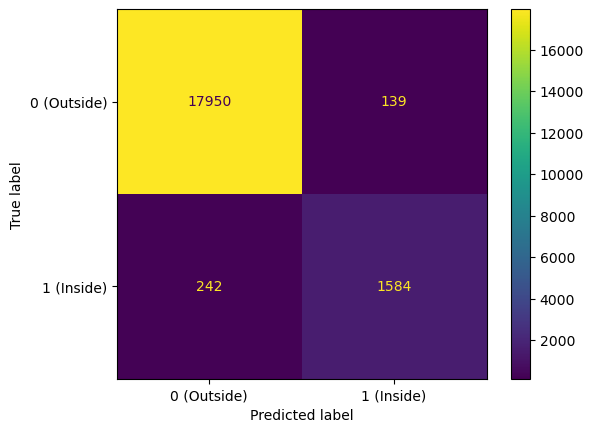

In [40]:
calculate_matrices (all_test_labels, test_token_predictions)

Comparing Results

The fine-tuned BERT model (seed 42) has a high performance with F1=0.893 for scope detection. The confusion matrix shows 139 false positives (tokens incorrectly included in scope) and 242 false negatives (in-scope tokens missed). The model prioritizes precision (92.4%) over recall (86.7%), meaning it's more likely to under-predict scope than over-predict it, and misses about 13% of in-scope tokens.

The BERT model has a much better performance than the A1. The F1-score increased by 12.3 percentage points (from 0.770 to 0.893), and it has a higher recall (from 0.715 to 0.867). This is expected due to BERT's contextual embeddings and self-attention, which can capture long-range dependencies between negation cues and their scopes. Using the replace method for cue encoding also helps BERT learn scope patterns for different cue types (affixes vs. single-word vs. multi-word cues), in contrast to the CRF model which only relies on features.

BERT’s Inside Scope F1 (89.3%) is significantly better than the CRF and SVM approaches used in shared task systems, which had F1 scores ranging from 82% to 86% (UiO2: 83.73%, FBK: 81.98%, UMichigan: 82.70%). BERT is pretrained on large corpora and can automatically learn rich linguistic features which removes the need for manual feature engineering like using dependency and constituency parsing information that was required in previous systems. It is good to keep in mind that the 2012 systems did the complete task including cue detection, but my we only focused on scope detection with preprocessed cue information.

Results from different seeds are very close. The F1 scores range from 0.893 (seed 42) to 0.899 (seed 101). The small variation shows that even with different random initializations, the models have all converged to similar solutions. The BERT model gave reliable and reproducible results, and the random seeds did not have much impact on the final performance of the models. There is a constant trade-off between precision and recall among different seeds, so the higher precision models have a lower recall. 


In [41]:
#save predictions to tsv
output_file = 'test_predictions.tsv'

with open(output_file, 'w', encoding='utf-8') as f:
    f.write("Sentence_ID\tToken\tGold_Label\tPredicted_Label\n")
    
    # Write predictions
    for sent_id, (tokens, gold, pred) in enumerate(zip(all_test_sentences, all_test_labels, test_token_predictions)): 
        for token, g, p in zip(tokens, gold, pred):
            #Convert integer labels to label_list
            f.write(f"{sent_id}\t{token}\t{label_list[g]}\t{label_list[p]}\n")
        f.write("\n")  # Blank line separates sentences

print(f"Predictions saved to: {output_file}")

Predictions saved to: test_predictions.tsv


In [42]:
seed = 42 #change
save_directory = f'./saved_model_seed_{seed}'
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)
print(f"Model saved")

Model saved


### **7 Standalone Function**

The predict() function allows you to use the fine-tuned BERT model to predict negation scope on new sentences. It takes a sentence (as a list of tokens) and the negation cue as input. It uses the same preprocessing as training, encoding cues with [CUE_0], [CUE_1], or [CUE_2]. It then tokenizes the input for BERT, predicts at the subword level, and aligns the predictions back to the original token level using majority voting. The output is a list of token-level predictions, where 1 indicates the token is inside the negation scope and 0 indicates it is outside.

In [43]:
import util
import numpy as np
from datasets import Dataset
from transformers import AutoModelForTokenClassification, AutoTokenizer, Trainer
from collections import Counter

def predict(sentence, neg_cue, model_path='./saved_model_seed_42'):
    """Standalone predict function for negation scope detection given a sentence and negation cue.

    Assumes only one negation cue in the sentence.

    args:
        sentence: List of strings for a sentence. e.g. ['I', 'do', 'not', 'like', 'apples']
        neg_cue: List of negation cues for the sentence, neg cue where available and '_' for other tokens.
            e.g. ['_', '_', 'not', '_', '_']
        model_path: path to the BERT model
    """
    # Preprocess the input
    processed_sentence = util.preprocessing_neg_bert_standalone(sentence, neg_cue)

    # Load the model from the model path
    model = AutoModelForTokenClassification.from_pretrained(model_path)
    #load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    #tokenize
    tokenized_sentence = tokenizer(processed_sentence, truncation=True, is_split_into_words=True)
    #Predict
    trainer = Trainer(model=model)
    standalone_dataset = Dataset.from_list([tokenized_sentence])
    predictions, labels, _ = trainer.predict(standalone_dataset)
    predictions = np.argmax(predictions, axis=2)
    
    #align subwords with tokens
    aligned_predictions = align_predictions_with_tokens(predictions, [processed_sentence], tokenizer)

    return aligned_predictions[0]

In [44]:
# Examples

sentence = ['I', 'do', 'not', 'like', 'apples']
cue = ['_', '_', 'not', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'do', 'not', 'like', 'apples', ',', 'but', 'I', 'love', 'strawberries']
cue = ['_', '_', 'not', '_', '_', '_', '_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'am', 'unimpressed', 'by', 'the', 'new', 'album']
cue = ['_', '_', 'un', '_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'like', 'oranges', '.']
cue = ['_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')


C:\Users\Rey\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Negation scope for the ['I', 'do', 'not', 'like', 'apples']: [1, 1, 0, 1, 1]


Negation scope for the ['I', 'do', 'not', 'like', 'apples', ',', 'but', 'I', 'love', 'strawberries']: [1, 1, 0, 1, 1, 0, 0, 0, 0, 0]


Negation scope for the ['I', 'am', 'unimpressed', 'by', 'the', 'new', 'album']: [1, 1, 0, 1, 1, 1, 1]


Negation scope for the ['I', 'like', 'oranges', '.']: [0, 0, 0, 0]
